In [1]:
import pandas as pd
import numpy as np
!pip install wfdb
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import wfdb

record = wfdb.rdrecord("s11_sit")

signals = record.p_signal

print(record.sig_name)

['ecg', 'pleth_1', 'pleth_2', 'pleth_3', 'pleth_4', 'pleth_5', 'pleth_6', 'lc_1', 'lc_2', 'temp_1', 'temp_2', 'temp_3', 'a_x', 'a_y', 'a_z', 'g_x', 'g_y', 'g_z']


In [17]:
import numpy as np

names = record.sig_name

red = signals[:, names.index("pleth_1")]
ir  = signals[:, names.index("pleth_2")]

fs = record.fs

time = np.arange(len(red))/fs

In [19]:
from scipy.signal import resample, butter, filtfilt, find_peaks, iirnotch
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter

def downsample(x,time, fs, fs_target=125):
    num_samples = int(np.round((len(x) * fs_target / fs)))
    x_resample = resample(x, num_samples)
    time_resample = np.linspace(time[0], time[-1], num_samples)
    return x_resample, time_resample

def baseline_correction(time, x, fs=125):
    min_distance = int(0.5 * fs) 
    # Menggunakan prominence relatif terhadap standar deviasi sinyal
    prominence_thresh = 0.2 * np.std(x)
    peaks, _ = find_peaks(-x, distance=min_distance, prominence=prominence_thresh)

    if len(peaks) < 2:
        # Fallback jika lembah terlalu sedikit
        baseline_dc = np.full_like(x, np.mean(x))
        return x - baseline_dc, np.abs(baseline_dc)
    
    t_val = time[peaks]
    s_val = x[peaks]

    # Mencegah edge effect dengan menyisipkan titik batas awal dan akhir
    if t_val[0] > time[0]:
        t_val = np.insert(t_val, 0, time[0])
        s_val = np.insert(s_val, 0, s_val[0])
    if t_val[-1] < time[-1]:
        t_val = np.append(t_val, time[-1])
        s_val = np.append(s_val, s_val[-1])

    cs = CubicSpline(t_val, s_val, bc_type='natural')
    baseline_dc = cs(time)
    
    # Pastikan DC tidak nol atau negatif murni
    baseline_dc = np.maximum(np.abs(baseline_dc), 1e-6)
    x_corrected = x - baseline_dc

    return x_corrected, baseline_dc

def bandpass(x, low_cut, high_cut, fs = 125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq

    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    x_clean = filtfilt(b, a, x)
    return x_clean

def ac_p2p(ac_signal, fs=125):
    min_distance = int(0.5 * fs)
    prominence_thresh = 0.2 * np.std(ac_signal)
    
    peaks, _ = find_peaks(ac_signal, distance=min_distance, prominence=prominence_thresh)
    troughs, _ = find_peaks(-ac_signal, distance=min_distance, prominence=prominence_thresh)
    
    if len(peaks) == 0 or len(troughs) == 0:
        return 0.0, peaks

    p2p_values = []
    # Memasangkan setiap peak dengan trough terdekat sebelum peak tersebut
    for p in peaks:
        valid_troughs = troughs[troughs < p]
        if len(valid_troughs) > 0:
            nearest_trough = valid_troughs[-1]
            amp = ac_signal[p] - ac_signal[nearest_trough]
            p2p_values.append(amp)
            
    if len(p2p_values) == 0:
        return 0.0, peaks

    return float(np.mean(p2p_values)), peaks

def Spo2(ac_ir, dc_ir, ac_red, dc_red):
    mean_dc_ir = np.mean(np.abs(dc_ir))
    mean_dc_red = np.mean(np.abs(dc_red))
    
    PI_red = ac_red / mean_dc_red
    PI_ir = ac_ir / mean_dc_ir

    R = PI_red / PI_ir
    spo2 = 3.069398 * (R**2) - 5.149127 * R + 99.794281
    spo2 = np.clip(spo2, 0, 100)
    return spo2, PI_red, PI_ir

def savgol(signal, window_size=11, poly_order=2):
    smoothed_signal = savgol_filter(signal, window_size, poly_order)
    return smoothed_signal



In [20]:
red_resample, time_ppg_resample = downsample(red, time, fs, 125)
ir_resample, _ = downsample(ir, time, fs, 125)

red_resample *= -1
ir_resample *= -1

red_corrected, dc_red = baseline_correction(time_ppg_resample, red_resample, fs=125)
ir_corrected, dc_ir = baseline_correction(time_ppg_resample, ir_resample, fs=125)

red_bpf = bandpass(red_corrected, 0.5, 15, fs=125)
ir_bpf  = bandpass(ir_corrected, 0.5, 15, fs=125)

red_smooth = savgol(red_bpf, window_size=11, poly_order=2)
ir_smooth  = savgol(ir_bpf, window_size=11, poly_order=2)

ac_red_amp, red_peaks = ac_p2p(red_smooth, fs=125)
ac_ir_amp, ir_peaks = ac_p2p(ir_smooth, fs=125)

spo2, PI_red, PI_ir = Spo2(ac_ir_amp, dc_ir, ac_red_amp, dc_red)

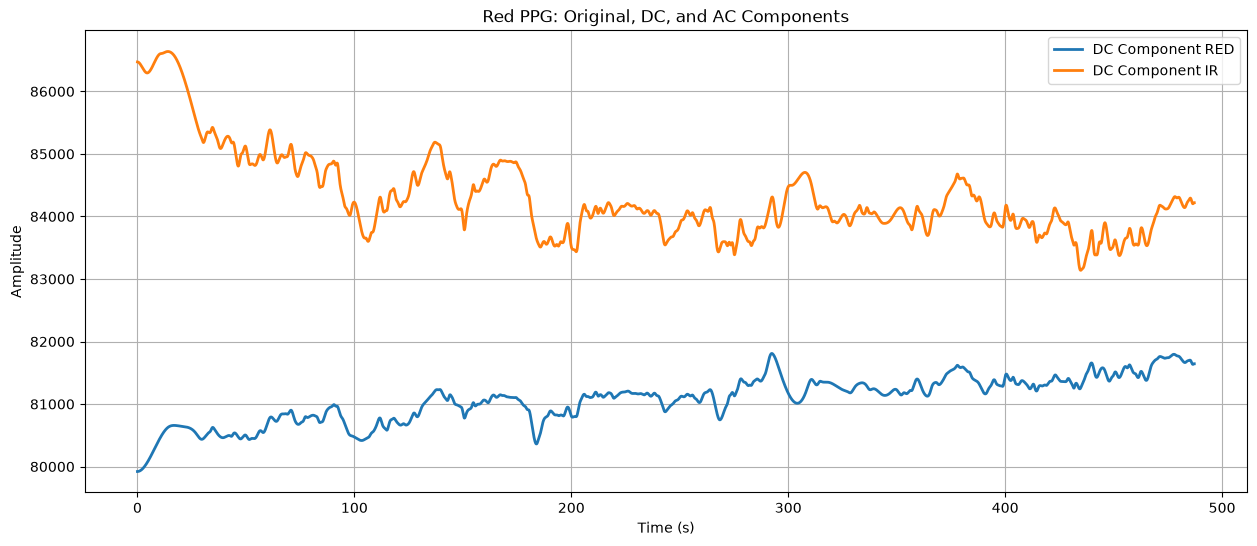

In [21]:
plt.figure(figsize=(15,6))


plt.plot(time_ppg_resample, dc_red,
         label='DC Component RED',
         linewidth=2)

plt.plot(time_ppg_resample, dc_ir,
         label='DC Component IR',
         linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Red PPG: Original, DC, and AC Components")
plt.legend()
plt.grid(True)

plt.show()

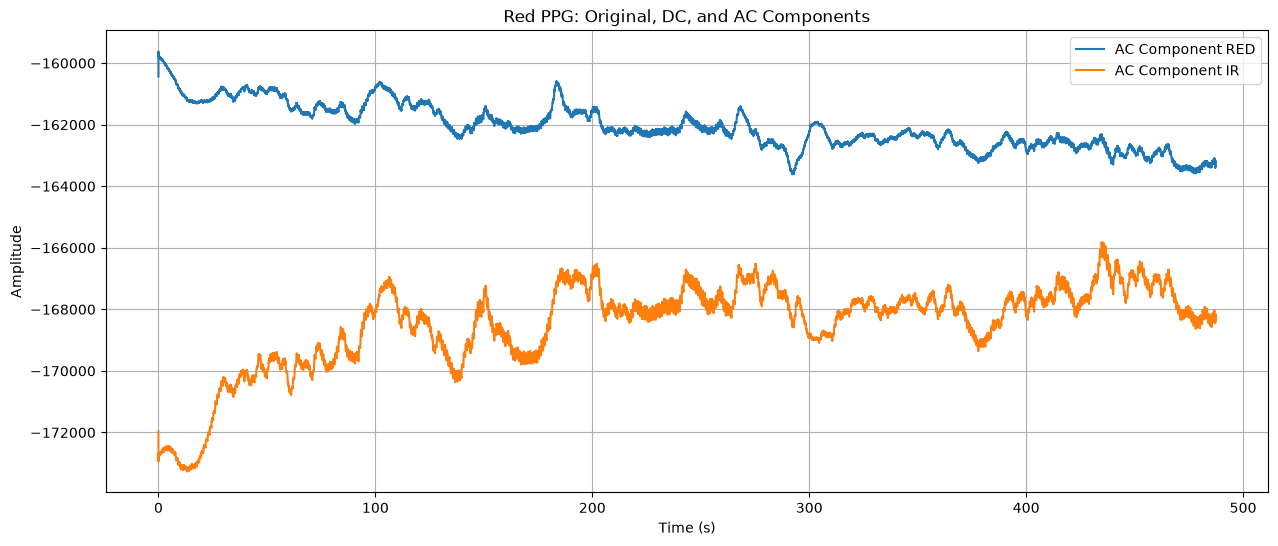

In [22]:
plt.figure(figsize=(15,6))
plt.plot(time_ppg_resample, red_corrected,
         label='AC Component RED')

plt.plot(time_ppg_resample, ir_corrected,
         label='AC Component IR')

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Red PPG: Original, DC, and AC Components")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
# ==========================
# Ground Truth dari file .hea
# ==========================

spo2_gt_start = 97
spo2_gt_end   = 98

# gunakan rata-rata sebagai referensi rekaman
spo2_gt = (spo2_gt_start + spo2_gt_end) / 2

print(f"Ground Truth SpO₂ : {spo2_gt:.2f}%")
print(f"Estimated SpO₂    : {spo2:.2f}%")



Ground Truth SpO₂ : 97.50%
Estimated SpO₂    : 98.13%
